Credit Card Fraud Detection
- Built ML model on 20,000 transactions with 1.6% fraud to reduce financial loss
- Addressed severe class imbalance using StratifiedKFold and class_weight='balanced'
- Achieved 84% recall for fraud class, catching 5 out of 6 fraudulent transactions


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import sklearn
import seaborn as s
import plotly.express as pe 
from sklearn.preprocessing._label import LabelEncoder

In [2]:
data=pd.read_csv('fraud.csv')
data.head()

,transaction_id,amount_usd,merchant_category,card_type,auth_method,channel,device_type,is_foreign_transaction,hours_since_last_txn,txn_count_last_24h,...,ip_country_mismatch,billing_shipping_mismatch,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,is_ai_generated_scam_attempt,merchant_risk_score,prior_disputes,is_fraud
0,1,42.86,Restaurants,Visa,OTP,Online,Android Phone,False,13.54,2,...,False,False,0,0.1,18,3,False,42.3,0,0
1,2,4.75,Online Retail,Mastercard,3D Secure,Online,Android Phone,False,0.71,2,...,False,False,0,25.8,12,4,False,28.3,0,0
2,3,77.18,Groceries,Mastercard,3D Secure,Online,Mac,False,0.35,5,...,False,True,0,42.3,5,0,False,24.7,1,0
3,4,1.69,Streaming,Visa,No Authentication,POS,Android Phone,False,3.42,6,...,False,False,0,28.9,22,6,False,56.2,1,0
4,5,261.68,Travel,Visa,3D Secure,In-App,iPhone,False,2.43,2,...,False,False,0,3.9,2,4,False,32.7,0,0


In [3]:
data.shape

(20000, 26)

In [4]:
data.columns

Index(['transaction_id', 'amount_usd', 'merchant_category', 'card_type',
       'auth_method', 'channel', 'device_type', 'is_foreign_transaction',
       'hours_since_last_txn', 'txn_count_last_24h', 'distance_from_home_km',
       'card_age_months', 'customer_age', 'account_balance_usd',
       'is_new_merchant', 'used_vpn', 'ip_country_mismatch',
       'billing_shipping_mismatch', 'cvv_retry_count', 'velocity_score',
       'time_of_day_hour', 'day_of_week', 'is_ai_generated_scam_attempt',
       'merchant_risk_score', 'prior_disputes', 'is_fraud'],
      dtype='object')

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   transaction_id                20000 non-null  int64  
 1   amount_usd                    20000 non-null  float64
 2   merchant_category             20000 non-null  object 
 3   card_type                     20000 non-null  object 
 4   auth_method                   20000 non-null  object 
 5   channel                       20000 non-null  object 
 6   device_type                   20000 non-null  object 
 7   is_foreign_transaction        20000 non-null  bool   
 8   hours_since_last_txn          20000 non-null  float64
 9   txn_count_last_24h            20000 non-null  int64  
 10  distance_from_home_km         20000 non-null  float64
 11  card_age_months               20000 non-null  int64  
 12  customer_age                  20000 non-null  int64  
 13  a

In [6]:
from sklearn.preprocessing._label import LabelEncoder
d_types=dict(data.dtypes)
for name,type_ in d_types.items():
    if str(type_)=='object':
        le=LabelEncoder()
        data[name]=le.fit_transform(data[name])

In [7]:
le=LabelEncoder()
data['is_foreign_transaction']=le.fit_transform(data['is_foreign_transaction'])
data['is_new_merchant']=data['is_new_merchant']
data['used_vpn']=le.fit_transform(data['used_vpn'])
data['ip_country_mismatch']=le.fit_transform(data['ip_country_mismatch'])
data['billing_shipping_mismatch']=le.fit_transform(data['billing_shipping_mismatch'])
data['is_ai_generated_scam_attempt']=le.fit_transform(data['is_ai_generated_scam_attempt'])
data['is_new_merchant']=le.fit_transform(data['is_new_merchant'])

In [8]:
data.head()

,transaction_id,amount_usd,merchant_category,card_type,auth_method,channel,device_type,is_foreign_transaction,hours_since_last_txn,txn_count_last_24h,...,ip_country_mismatch,billing_shipping_mismatch,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,is_ai_generated_scam_attempt,merchant_risk_score,prior_disputes,is_fraud
0,1,42.86,8,4,3,3,1,0,13.54,2,...,0,0,0,0.1,18,3,0,42.3,0,0
1,2,4.75,7,2,0,3,1,0,0.71,2,...,0,0,0,25.8,12,4,0,28.3,0,0
2,3,77.18,5,2,0,3,2,0,0.35,5,...,0,1,0,42.3,5,0,0,24.7,1,0
3,4,1.69,9,4,2,4,1,0,3.42,6,...,0,0,0,28.9,22,6,0,56.2,1,0
4,5,261.68,10,4,0,2,7,0,2.43,2,...,0,0,0,3.9,2,4,0,32.7,0,0


In [9]:
for col in data.columns:
    print(col,len(data[col].unique())/len(data))

transaction_id 1.0
amount_usd 0.6391
merchant_category 0.0006
card_type 0.00025
auth_method 0.00025
channel 0.00025
device_type 0.0004
is_foreign_transaction 0.0001
hours_since_last_txn 0.1648
txn_count_last_24h 0.00065
distance_from_home_km 0.30605
card_age_months 0.0026
customer_age 0.0032
account_balance_usd 0.98145
is_new_merchant 0.0001
used_vpn 0.0001
ip_country_mismatch 0.0001
billing_shipping_mismatch 0.0001
cvv_retry_count 0.0002
velocity_score 0.0317
time_of_day_hour 0.0012
day_of_week 0.00035
is_ai_generated_scam_attempt 0.0001
merchant_risk_score 0.047
prior_disputes 0.00025
is_fraud 0.0001


In [10]:
data=data.drop(['transaction_id'],axis=1)

In [11]:
remaining_columns=list(data.columns)
remaining_columns.remove('is_fraud')

In [12]:
X=data[remaining_columns].values
Y=data['is_fraud'].values.astype(np.uint8)

In [13]:
from sklearn.metrics import recall_score,precision_score,classification_report,confusion_matrix
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import RFECV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
kfold=StratifiedKFold(n_splits=5)
fraud=[]
fraud_recall=[]
for train_idx,test_idx in kfold.split(X,Y):
    Xtrain=X[train_idx]
    Ytrain=Y[train_idx]

    Xtest=X[test_idx]
    Ytest=Y[test_idx]

    scaler=StandardScaler()
    Xtrain=scaler.fit_transform(Xtrain)
    Xtest=scaler.transform(Xtest)
    
    model=LogisticRegression(max_iter=800,class_weight='balanced')
    rfecv=RFECV(model,step=1,min_features_to_select=6,n_jobs=-1)
    rfecv.fit(Xtrain,Ytrain)
    
    rfecv.fit(Xtrain,Ytrain)
    fraud.append(rfecv.score(Xtest,Ytest))
    predictions=rfecv.predict(Xtest)
    fraud_recall.append(recall_score(Ytest,predictions))

In [14]:
print('features selected:',rfecv.n_features_)

features selected: 19


kfold varidation mean: 0.8648999999999999


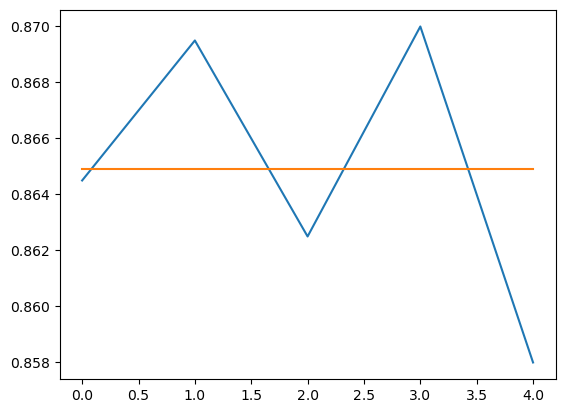

In [15]:
print('kfold varidation mean:',np.mean(fraud))
plt.plot(fraud)
plt.plot([np.mean(fraud)]*len(fraud))

In [16]:
print(classification_report(Ytest,predictions))

              precision    recall  f1-score   support

           0       1.00      0.86      0.92      3932
           1       0.09      0.84      0.17        68

    accuracy                           0.86      4000
   macro avg       0.54      0.85      0.54      4000
weighted avg       0.98      0.86      0.91      4000



<Axes: >

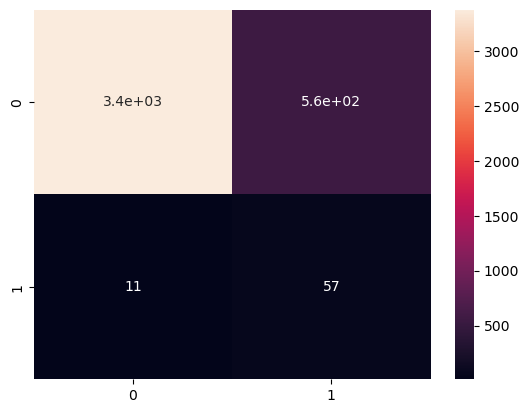

In [17]:
s.heatmap(confusion_matrix(Ytest,predictions),annot=True)